# Terzaghi 1D Multi-Layer

Demo for the 1D Multi layer FEM model to get settlement.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d_multi.fem import Get_terzaghi1dMultilayer_FEA
from src.plotting.terzaghi_1d.plot import Get_Settlement_Plot

sns.set_theme(style="whitegrid")

load = 100.0
base = 2
num = 100
depths = [1.5, 3.0, 5.0]
Cv = [2e-7, 1e-7, 3e-7]  # Cv = [6.3072, 3.1536, 9.4608] m2/yr
Mv = [5e-4, 8e-4, 4e-4]
T = (24 * 60 * 60) * 365
time_steps = 1000
use_uniform_u0 = False

H = max(depths)
nodes = num + 1
z = -np.linspace(0.0, H, nodes)
time_day = np.linspace(0.0, T / (60 * 60 * 24), time_steps)

# Permeability per layer from Cv and Mv
w_w = 9.81   # (kN/m3)
k_list  = [Cv_i * Mv_i * w_w for Cv_i, Mv_i in zip(Cv, Mv)]

df_layers = pd.DataFrame({
    "Layer": np.arange(1, len(Cv) + 1),
    "Cv (m²/s)": Cv,
    "Mv (m²/kN)": Mv,
    "k (m/s)": k_list
})

df_layers

,Layer,Cv (m²/s),Mv (m²/kN),k (m/s)
0,1,2.000000e-07,0.0005,9.810000e-10
1,2,1.000000e-07,0.0008,7.848000e-10
2,3,3.000000e-07,0.0004,1.177200e-09


## Solve the Multilayer Model

u_hist shape:             (1000, 101)
settlement_history shape: (1000,)
Final settlement:         0.098204 m
Total Settlement:         0.150852


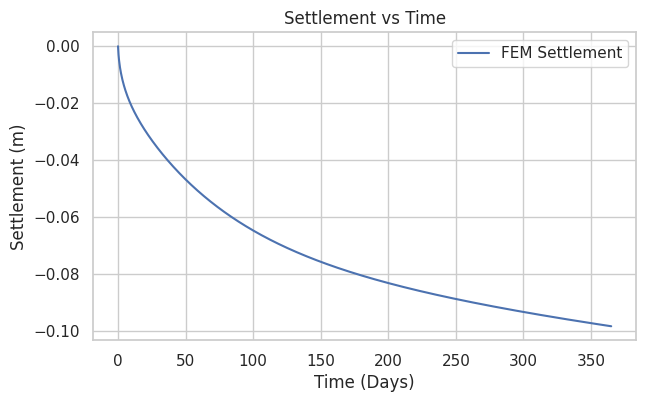

In [2]:
settlement_history, u_hist, settlement_profile = Get_terzaghi1dMultilayer_FEA( depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=False)

print(f"u_hist shape:             {u_hist.shape}")
print(f"settlement_history shape: {settlement_history.shape}")
print(f"Final settlement:         {settlement_history[-1]:.6f} m")
print(f"Total Settlement:         {np.sum(settlement_profile):.6f}")

fig, ax = Get_Settlement_Plot( settlement_history , time_day)

## Qaudatrue Settlement Sum

### for np.sum 

Final settlement:         0.098144 m

Total Settlement:         0.150852



### for np.trapezoid 

Final settlement:         0.098204 m

Total Settlement:         0.150852 m

## Settle3 Comparison



In [3]:
file = 'settle3_data/settle3_1d_multilayer.xlsx'

settle3_1y = pd.read_excel(file, sheet_name='2. Stage 2 = 1 y')['Total Consolidation Settlement'].iloc[0]
settle3_1000y = pd.read_excel(file, sheet_name='3. Stage 3 = 1000 y')['Total Consolidation Settlement'].iloc[0]

results = pd.DataFrame(
    {
        'Settle3': [settle3_1y, settle3_1000y],
        'FEM Rectangle': [0.098144, 0.150852],
        'FEM Trapezoid': [0.098204, 0.150852],
    },
    index=['1 year', '1000 year']
)

results['Rectangle % Difference to Settle3'] = 100.0 * (results['FEM Rectangle'] - results['Settle3']) / results['Settle3']
results['Trapezoid % Difference to Settle3'] = 100.0 * (results['FEM Trapezoid'] - results['Settle3']) / results['Settle3']

results


,Settle3,FEM Rectangle,FEM Trapezoid,Rectangle % Difference to Settle3,Trapezoid % Difference to Settle3
1 year,0.094917,0.098144,0.098204,3.400299,3.463512
1000 year,0.151959,0.150852,0.150852,-0.728255,-0.728255


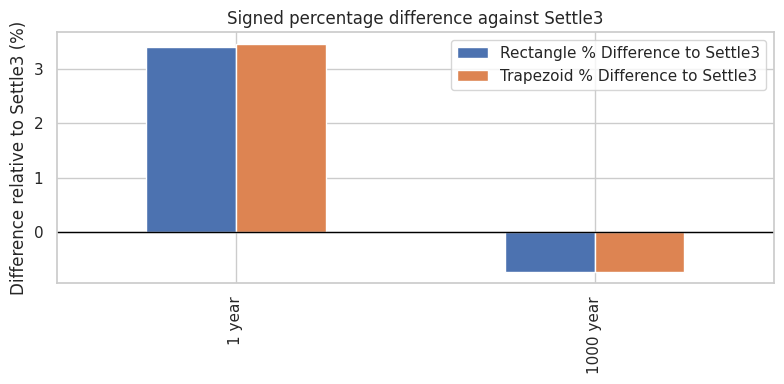

,Rectangle % Difference to Settle3,Trapezoid % Difference to Settle3
1 year,3.400299,3.463512
1000 year,-0.728255,-0.728255


In [4]:
percent_difference = results[[
    'Rectangle % Difference to Settle3',
    'Trapezoid % Difference to Settle3',
]]

ax = percent_difference.plot(kind='bar', figsize=(8, 4))
ax.axhline(0.0, color='black', linewidth=1.0)
ax.set_ylabel('Difference relative to Settle3 (%)')
ax.set_title('Signed percentage difference against Settle3')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

percent_difference
